📥 Loading features, embeddings, scorer...
Embeddings shape: (20400, 64)
Unique users: 51
EER threshold: 0.5340709924763434
FAR=1% threshold: 0.9281687319642788

Sample of keystroke samples:
   user_id  session_id  idx
0        2           1    0
1        2           1    1
2        2           1    2
3        2           1    3
4        2           1    4

User sample counts (top 10):
user_id
2     400
44    400
34    400
35    400
36    400
37    400
38    400
39    400
40    400
41    400
Name: count, dtype: int64

Chosen genuine user: 2
Chosen impostor user: 44
Genuine samples: 400
Impostor samples: 400

Stream length: 120
First part genuine, then impostor.

Enrollment size: 20
Reference embedding shape: (64,)

Stream with scores and policy:
   user_id  session_id  idx  is_impostor  score_same   policy
0        2           1   20            0    0.875522  MONITOR
1        2           1   21            0    0.857105  MONITOR
2        2           1   22            0    0.916004  MONIT

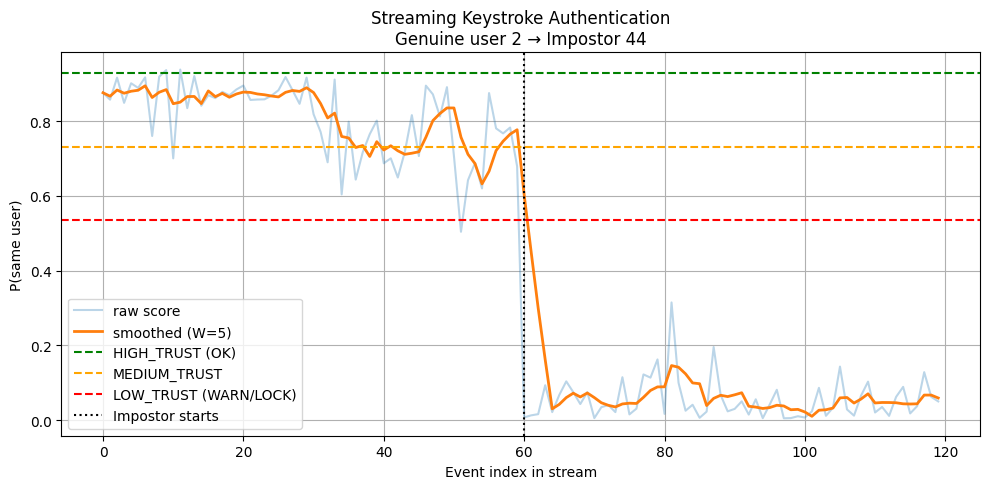


Rows around intrusion point:


,idx,user_id,is_impostor,score_same,score_smooth,policy_smooth
55,75,2,0,0.874708,0.665581,WARN
56,76,2,0,0.780268,0.720879,WARN
57,77,2,0,0.766928,0.745893,MONITOR
58,78,2,0,0.782562,0.764819,MONITOR
59,79,2,0,0.678726,0.776638,MONITOR
60,15200,44,1,0.007354,0.603168,WARN
61,15201,44,1,0.012837,0.449681,LOCK
62,15202,44,1,0.016032,0.299502,LOCK
63,15203,44,1,0.093407,0.161671,LOCK
64,15204,44,1,0.021474,0.030221,LOCK


In [2]:
# ============================================================
# 05_streaming_demo.ipynb
# Adaptive Continuous Authentication — Keystroke Streaming Demo
# ============================================================

"""
Goal:
  - Simulate a continuous keystroke authentication scenario
  - Use:
      * keystroke CLS embeddings (per repetition)
      * trained pairwise scorer (same-user vs impostor)
  - Scenario:
      * First part of stream: genuine user's keystrokes
      * Second part: impostor's keystrokes mixed in
  - For each event:
      * Compare current embedding to an enrollment template
      * Compute probability of "same user"
      * Map score to risk level and policy action

This is a conceptual demo; real systems would work on event-level timing
rather than precomputed repetitions, but the logic is the same.
"""

# ============================================================
# Setup
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import json
import random
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

DATA_DIR = Path("data")
EMB_DIR = Path("embeddings")
MODEL_DIR = Path("models")

FEATURES_PATH = DATA_DIR / "keystroke_features.npz"
EMB_CLS_PATH = EMB_DIR / "keystroke_embeddings_cls.npy"
SCORER_PATH  = MODEL_DIR / "keystroke_scorer.joblib"
META_PATH    = MODEL_DIR / "keystroke_scoring_meta.json"

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ============================================================
# 1. Load data, embeddings, and scorer
# ============================================================

print("📥 Loading features, embeddings, scorer...")

meta = np.load(FEATURES_PATH, allow_pickle=True)
users = meta["user_id"].astype(int)
sessions = meta["session_id"].astype(int)
X_behav = meta["features"].astype(np.float32)

Z = np.load(EMB_CLS_PATH).astype(np.float32)  # (N, 64)

scorer = joblib.load(SCORER_PATH)

with open(META_PATH, "r") as f:
    scoring_meta = json.load(f)

print("Embeddings shape:", Z.shape)
print("Unique users:", len(np.unique(users)))

# Thresholds from scoring_meta
thr_eer = scoring_meta["eer_threshold"]
thr_far1 = scoring_meta["threshold_far_1pct"]
print("EER threshold:", thr_eer)
print("FAR=1% threshold:", thr_far1)

# ============================================================
# 2. Build a DataFrame for convenience
# ============================================================

df = pd.DataFrame({
    "user_id": users,
    "session_id": sessions,
    # We'll add an index for referencing embeddings
    "idx": np.arange(len(users))
})

# For reproducibility, sort by user, then session, then index
df.sort_values(["user_id", "session_id", "idx"], inplace=True)
df.reset_index(drop=True, inplace=True)

print("\nSample of keystroke samples:")
print(df.head())

# ============================================================
# 3. Choose a genuine user and an impostor
# ============================================================

# Pick a user with a decent number of samples
user_counts = df["user_id"].value_counts()
print("\nUser sample counts (top 10):")
print(user_counts.head(10))

# Choose the most frequent user as the genuine one
genuine_user = int(user_counts.index[0])
print("\nChosen genuine user:", genuine_user)

# Choose a different user as impostor
impostor_user = int([u for u in user_counts.index if u != genuine_user][0])
print("Chosen impostor user:", impostor_user)

df_genuine_all = df[df["user_id"] == genuine_user].copy()
df_impostor_all = df[df["user_id"] == impostor_user].copy()

print("Genuine samples:", len(df_genuine_all))
print("Impostor samples:", len(df_impostor_all))

# ============================================================
# 4. Build a synthetic stream: genuine first, then impostor
# ============================================================

# Parameters for the demo
N_ENROLL = 20    # enrollment samples (initial reference)
N_GENUINE_STREAM = 60
N_IMPOSTOR_STREAM = 60

# Take some genuine samples for enrollment + stream
df_genuine_all = df_genuine_all.iloc[:(N_ENROLL + N_GENUINE_STREAM)].copy()
# Take impostor samples for intrusion
df_impostor_all = df_impostor_all.iloc[:N_IMPOSTOR_STREAM].copy()

# Enrollment set: first N_ENROLL genuine
df_enroll = df_genuine_all.iloc[:N_ENROLL]
# Genuine stream: remaining genuine
df_genuine_stream = df_genuine_all.iloc[N_ENROLL:]

# Concatenate: genuine stream followed by impostor stream
df_stream = pd.concat(
    [
        df_genuine_stream.assign(is_impostor=0),
        df_impostor_all.assign(is_impostor=1),
    ],
    ignore_index=True
)

print("\nStream length:", len(df_stream))
print("First part genuine, then impostor.")

intrusion_start = len(df_genuine_stream)  # index where impostor starts

# ============================================================
# 5. Enrollment template (reference embedding)
# ============================================================

# Compute reference embedding as the mean of enrollment embeddings
enroll_indices = df_enroll["idx"].values
Z_enroll = Z[enroll_indices]
ref_embedding = Z_enroll.mean(axis=0).astype(np.float32)

print("\nEnrollment size:", Z_enroll.shape[0])
print("Reference embedding shape:", ref_embedding.shape)

# ============================================================
# 6. Helper: pair feature builder + scoring + risk mapping
# ============================================================

def make_pair_features(z_ref, z_curr):
    """
    Match the pairwise features used for scorer training:
      [ |z_ref - z_curr| , z_ref * z_curr ]
    """
    diff = np.abs(z_ref - z_curr)
    prod = z_ref * z_curr
    return np.concatenate([diff, prod]).reshape(1, -1).astype(np.float32)

def score_same_user(z_ref, z_curr):
    X_pair = make_pair_features(z_ref, z_curr)
    prob_same = scorer.predict_proba(X_pair)[0, 1]
    return float(prob_same)

# Risk policy mapping based on calibrated thresholds
HIGH_TRUST = thr_far1          # ~0.93 from your run
LOW_TRUST = thr_eer            # ~0.53 from your run
# You can tweak this mid-level threshold
MEDIUM_TRUST = (HIGH_TRUST + LOW_TRUST) / 2.0

def risk_policy(score):
    """
    Map probability of "same user" to policy state:
      - OK      : high confidence it's the genuine user
      - MONITOR : mild suspicion
      - WARN    : significant suspicion
      - LOCK    : likely impostor
    """
    if score >= HIGH_TRUST:
        return "OK"
    elif score >= MEDIUM_TRUST:
        return "MONITOR"
    elif score >= LOW_TRUST:
        return "WARN"
    else:
        return "LOCK"

# ============================================================
# 7. Streaming simulation
# ============================================================

scores = []
policies = []

for t, row in df_stream.iterrows():
    idx = int(row["idx"])
    z_curr = Z[idx]
    s = score_same_user(ref_embedding, z_curr)
    scores.append(s)
    policies.append(risk_policy(s))

df_stream["score_same"] = scores
df_stream["policy"] = policies

print("\nStream with scores and policy:")
print(df_stream.head())

# ============================================================
# 8. Simple smoothing (optional)
# ============================================================

# Sliding window smoothing over last W scores
W = 5
smoothed_scores = []
for i in range(len(scores)):
    start = max(0, i - W + 1)
    smoothed_scores.append(np.mean(scores[start:i+1]))
df_stream["score_smooth"] = smoothed_scores

# Optionally, recompute policy based on smoothed scores
df_stream["policy_smooth"] = df_stream["score_smooth"].apply(risk_policy)

# ============================================================
# 9. Visualization
# ============================================================

plt.figure(figsize=(10, 5))
t = np.arange(len(df_stream))

# Plot raw and smoothed scores
plt.plot(t, df_stream["score_same"], alpha=0.3, label="raw score")
plt.plot(t, df_stream["score_smooth"], linewidth=2, label=f"smoothed (W={W})")

# Mark thresholds
plt.axhline(HIGH_TRUST, color="green", linestyle="--", label="HIGH_TRUST (OK)")
plt.axhline(MEDIUM_TRUST, color="orange", linestyle="--", label="MEDIUM_TRUST")
plt.axhline(LOW_TRUST, color="red", linestyle="--", label="LOW_TRUST (WARN/LOCK)")

# Vertical line where impostor starts
plt.axvline(intrusion_start, color="black", linestyle=":", label="Impostor starts")

plt.xlabel("Event index in stream")
plt.ylabel("P(same user)")
plt.title(f"Streaming Keystroke Authentication\nGenuine user {genuine_user} → Impostor {impostor_user}")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.savefig("streaming_scores_plot.png", dpi=200, bbox_inches="tight")
plt.show()

# Show a small table around the intrusion point
print("\nRows around intrusion point:")
display(df_stream.iloc[max(0, intrusion_start-5):intrusion_start+10][
    ["idx", "user_id", "is_impostor", "score_same", "score_smooth", "policy_smooth"]
])